In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set aesthetic style for visualizations
sns.set_theme(style="whitegrid")
np.random.seed(42)

In [2]:
print("Generating synthetic retail dataset...")
n_records = 1500

data = {
    'Transaction_ID': np.arange(10000, 10000 + n_records),
    'Date': pd.date_range(start='2024-01-01', periods=n_records, freq='h'),
    'Product_Category': np.random.choice(['Electronics', 'Clothing', 'Home & Kitchen', 'Beauty'], size=n_records, p=[0.3, 0.4, 0.2, 0.1]),
    'Units_Sold': np.random.randint(1, 6, size=n_records),
    'Unit_Price': np.round(np.random.uniform(10.0, 150.0, size=n_records), 2),
    'Discount_Pct': np.random.choice([0.0, 0.05, 0.10, 0.20], size=n_records, p=[0.6, 0.2, 0.1, 0.1])
}

df = pd.DataFrame(data)

# Feature Engineering: Calculate Gross and Net Revenue
df['Gross_Sales'] = df['Units_Sold'] * df['Unit_Price']
df['Total_Sales'] = np.round(df['Gross_Sales'] * (1 - df['Discount_Pct']), 2)

# Extract Time Intelligence Features
df['Month'] = df['Date'].dt.month
df['Day_of_Week'] = df['Date'].dt.dayofweek
df['Hour'] = df['Date'].dt.hour

print(f"Dataset generated with {df.shape[0]} transaction logs.\n")
display(df.head())

Generating synthetic retail dataset...
Dataset generated with 1500 transaction logs.



,Transaction_ID,Date,Product_Category,Units_Sold,Unit_Price,Discount_Pct,Gross_Sales,Total_Sales,Month,Day_of_Week,Hour
0,10000,2024-01-01 00:00:00,Clothing,2,12.71,0.05,25.42,24.15,1,0,0
1,10001,2024-01-01 01:00:00,Beauty,4,27.41,0.00,109.64,109.64,1,0,1
2,10002,2024-01-01 02:00:00,Home & Kitchen,5,67.91,0.00,339.55,339.55,1,0,2
3,10003,2024-01-01 03:00:00,Clothing,5,79.00,0.05,395.00,375.25,1,0,3
4,10004,2024-01-01 04:00:00,Electronics,2,66.60,0.05,133.20,126.54,1,0,4


In [3]:
print("\n--- Key Financial Performance Indicators ---")
total_revenue = df['Total_Sales'].sum()
avg_order_value = df['Total_Sales'].mean()
total_units = df['Units_Sold'].sum()

print(f"Total Generated Revenue: ${total_revenue:,.2f}")
print(f"Average Order Value (AOV): ${avg_order_value:.2f}")
print(f"Total Volume of Units Handled: {total_units:,}")

# Category Breakdown
category_summary = df.groupby('Product_Category').agg(
    Revenue=('Total_Sales', 'sum'),
    Items_Sold=('Units_Sold', 'sum')
).sort_values(by='Revenue', ascending=False)

print("\n--- Sales Performance Matrix by Product Category ---")
display(category_summary)


--- Key Financial Performance Indicators ---
Total Generated Revenue: $349,143.73
Average Order Value (AOV): $232.76
Total Volume of Units Handled: 4,593

--- Sales Performance Matrix by Product Category ---


,Revenue,Items_Sold
Product_Category,,
Clothing,139652.45,1863
Electronics,102795.23,1413
Home & Kitchen,71516.25,869
Beauty,35179.80,448


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17248\606078797.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Product_Category', y='Total_Sales', estimator=sum, errorbar=None, palette='viridis', ax=axes[0])


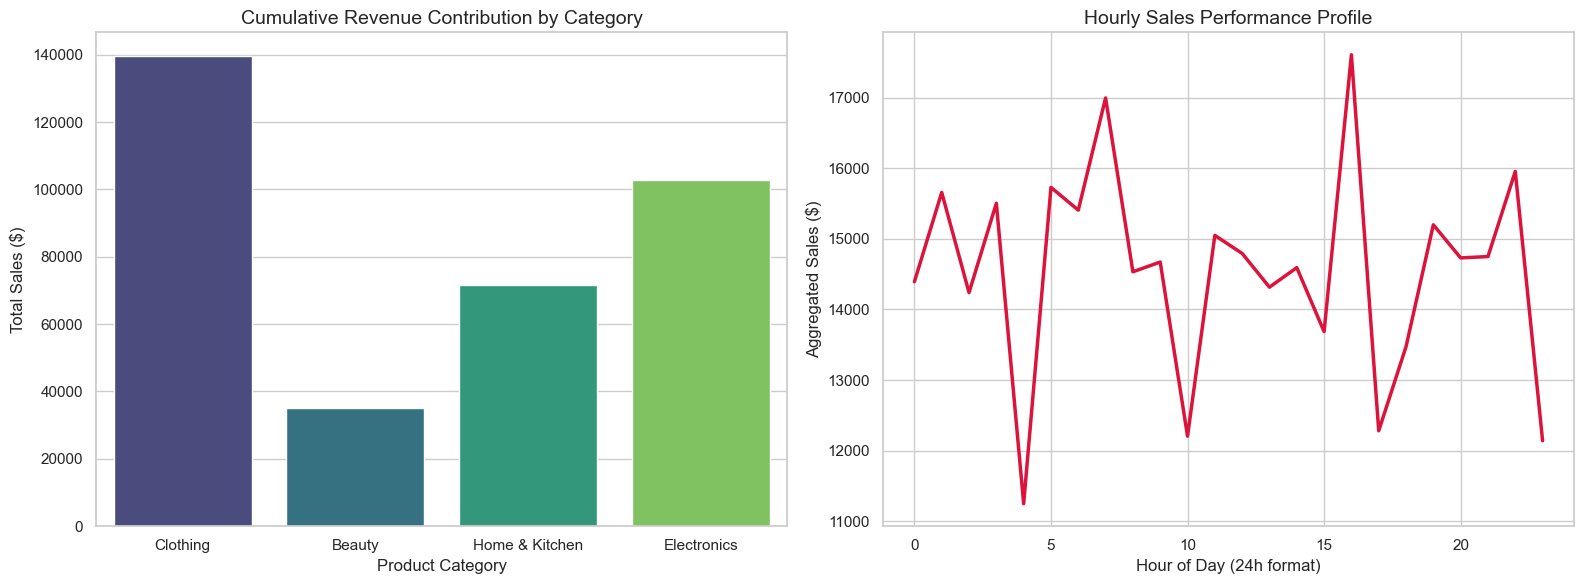

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Revenue Generation by Product Category
sns.barplot(data=df, x='Product_Category', y='Total_Sales', estimator=sum, errorbar=None, palette='viridis', ax=axes[0])
axes[0].set_title('Cumulative Revenue Contribution by Category', fontsize=14)
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Total Sales ($)')

# Plot 2: Hourly Transaction Volume
sns.lineplot(data=df, x='Hour', y='Total_Sales', estimator=sum, errorbar=None, color='crimson', lw=2.5, ax=axes[1])
axes[1].set_title('Hourly Sales Performance Profile', fontsize=14)
axes[1].set_xlabel('Hour of Day (24h format)')
axes[1].set_ylabel('Aggregated Sales ($)')

plt.tight_layout()
plt.show()


--- Training Predictive Modeling Baseline ---
Model Mean Squared Error (MSE): 3336.24
Model R-squared ($R^2$) Variance Score: 0.8836


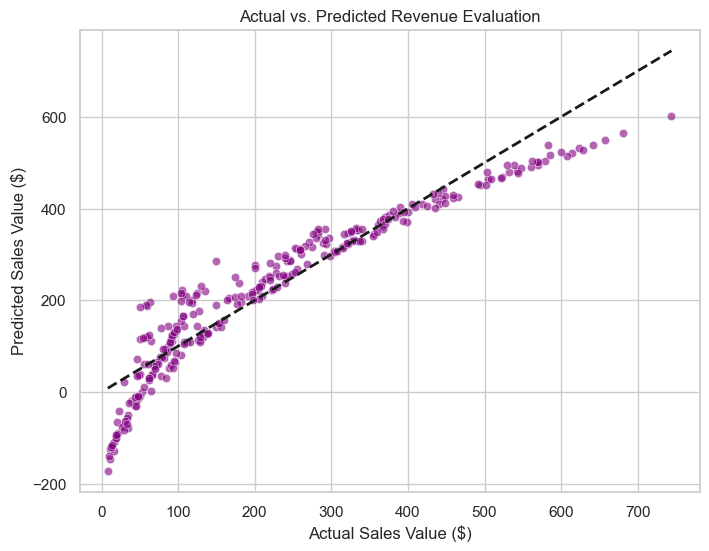

In [5]:
print("\n--- Training Predictive Modeling Baseline ---")

# Define target and predictors (Predict Total Sales based on transactional configurations)
# Categorical values are converted into dummy/one-hot indicators
X = pd.get_dummies(df[['Product_Category', 'Units_Sold', 'Unit_Price', 'Discount_Pct', 'Month', 'Day_of_Week']], drop_first=True)
y = df['Total_Sales']

# Evaluation split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression Training
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# Evaluate predictions
y_pred = reg_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Mean Squared Error (MSE): {mse:.2f}")
print(f"Model R-squared ($R^2$) Variance Score: {r2:.4f}")

# Plotting Predictions vs Actual values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Sales Value ($)')
plt.ylabel('Predicted Sales Value ($)')
plt.title('Actual vs. Predicted Revenue Evaluation')
plt.show()